In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import uproot
import awkward as ak
import collections

In [ ]:
#load Sim_D2ODetector013.root
path = "/raid1/genli/G4d2o_simulations/batch_20260319_180147/job_0/Sim_D2ODetector000.root"
file = uproot.open(path)
# Check the keys in the ROOT file
print(file.keys())

Sim_Tree = file["Sim_Tree"]
# Check the branches in the tree
print(Sim_Tree.keys())
event_data = Sim_Tree["eventData"]
print(event_data.keys())
# Show all branches in the eventData
event_data.show()

In [3]:
# Show the first 100 entries of eventData sourceParticlePDG
if "sourceParticlePDG" not in event_data.keys():
    print("sourceParticlePDG branch not found. Available branches:")
    print(event_data.keys())
else:
    source_particle_pdg = event_data["sourceParticlePDG"].array()
    first_100_source_particle_pdg = source_particle_pdg[:100]
    
    print("First 100 entries of sourceParticlePDG:")
    print(ak.to_list(first_100_source_particle_pdg))

First 100 entries of sourceParticlePDG:
[22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22]


In [3]:
# Inspect pmtHits branch, apply quality cut, then create totalPE per event
if "pmtHits" not in event_data.keys():
    print("pmtHits branch not found. Available branches:")
    print(event_data.keys())
else:
    pmt_hits_branch = event_data["pmtHits"]
    pmt_hits = pmt_hits_branch.array()
    
    # Extract pmtNum jagged array (one variable-length list per event)
    pmt_num = pmt_hits["pmtHits.pmtNum"]
    n_events_all = len(pmt_num)
    
    # Quality cut: each PMT index (0-11) must appear at least twice in the event
    pass_mask = []
    for evt in pmt_num:
        evt_np = np.asarray(ak.to_numpy(evt), dtype=np.int64)
        counts_12 = np.bincount(evt_np, minlength=12)[:12]
        pass_mask.append(np.all(counts_12 >= 2))
    pass_mask = np.asarray(pass_mask, dtype=bool)
    
    # Apply quality cut
    pmt_num_sel = pmt_num[pass_mask]
    pmt_hits_sel = pmt_hits[pass_mask]
    
    # New event-level entry after quality cut: totalPE = number of PMT hits in each selected event
    totalPE = ak.num(pmt_num_sel, axis=1)
    pmt_hits_sel = ak.with_field(pmt_hits_sel, totalPE, "totalPE")
    
    print(f"Events before cut: {n_events_all}")
    print(f"Events after cut : {len(pmt_num_sel)}")
    print(f"Cut efficiency   : {len(pmt_num_sel) / n_events_all:.4f}")
    print("pmtNum (selected) awkward type:", ak.type(pmt_num_sel))
    print("totalPE awkward type:", ak.type(totalPE))
    print("First 10 totalPE values after cut:", ak.to_list(totalPE[:10]))
    
    print("\nFirst 5 selected events pmtNum:")
    for i, evt in enumerate(pmt_num_sel[:5]):
        print(f"Event {i}: {ak.to_list(evt)}")
    
    # Flatten selected hits across events to inspect global pmtNum usage
    pmt_num_flat = ak.to_numpy(ak.flatten(pmt_num_sel))
    print("\nTotal selected PMT hits:", len(pmt_num_flat))
    if len(pmt_num_flat) > 0:
        vals, counts = np.unique(pmt_num_flat, return_counts=True)
        print("Unique PMT numbers:", vals)
        print("Counts per PMT (selected events):")
        for v, c in zip(vals, counts):
            print(f"  PMT {v}: {c}")
    else:
        print("No PMT hits found after quality cut.")

Events before cut: 100000
Events after cut : 89377
Cut efficiency   : 0.8938
pmtNum (selected) awkward type: 89377 * var * int32
totalPE awkward type: 89377 * int64
First 10 totalPE values after cut: [65, 194, 523, 333, 324, 175, 171, 254, 171, 142]

First 5 selected events pmtNum:
Event 0: [0, 2, 8, 8, 1, 7, 10, 10, 11, 10, 3, 11, 5, 11, 7, 6, 6, 7, 6, 11, 1, 6, 0, 6, 6, 6, 0, 7, 2, 6, 11, 4, 9, 5, 3, 9, 8, 2, 11, 4, 8, 7, 6, 2, 11, 3, 7, 2, 1, 8, 3, 1, 9, 11, 7, 7, 10, 11, 0, 8, 5, 1, 4, 8, 5]
Event 1: [11, 8, 3, 10, 3, 3, 10, 2, 7, 11, 11, 1, 9, 10, 5, 6, 0, 8, 5, 7, 8, 10, 11, 2, 4, 11, 6, 0, 11, 10, 5, 8, 7, 1, 3, 0, 7, 9, 8, 6, 11, 6, 0, 4, 3, 8, 5, 5, 7, 7, 6, 2, 7, 2, 6, 8, 2, 11, 2, 11, 9, 6, 11, 8, 5, 5, 7, 9, 6, 9, 6, 7, 8, 5, 5, 0, 7, 8, 0, 11, 9, 10, 1, 2, 2, 1, 11, 5, 9, 0, 2, 9, 2, 6, 6, 0, 7, 10, 4, 2, 2, 1, 11, 7, 5, 10, 1, 0, 8, 7, 2, 4, 3, 0, 5, 5, 6, 6, 6, 6, 0, 8, 7, 5, 8, 4, 9, 4, 7, 6, 2, 2, 2, 4, 5, 1, 6, 2, 9, 0, 9, 5, 7, 7, 6, 10, 7, 0, 1, 2, 11, 4, 1, 5, 6, 7

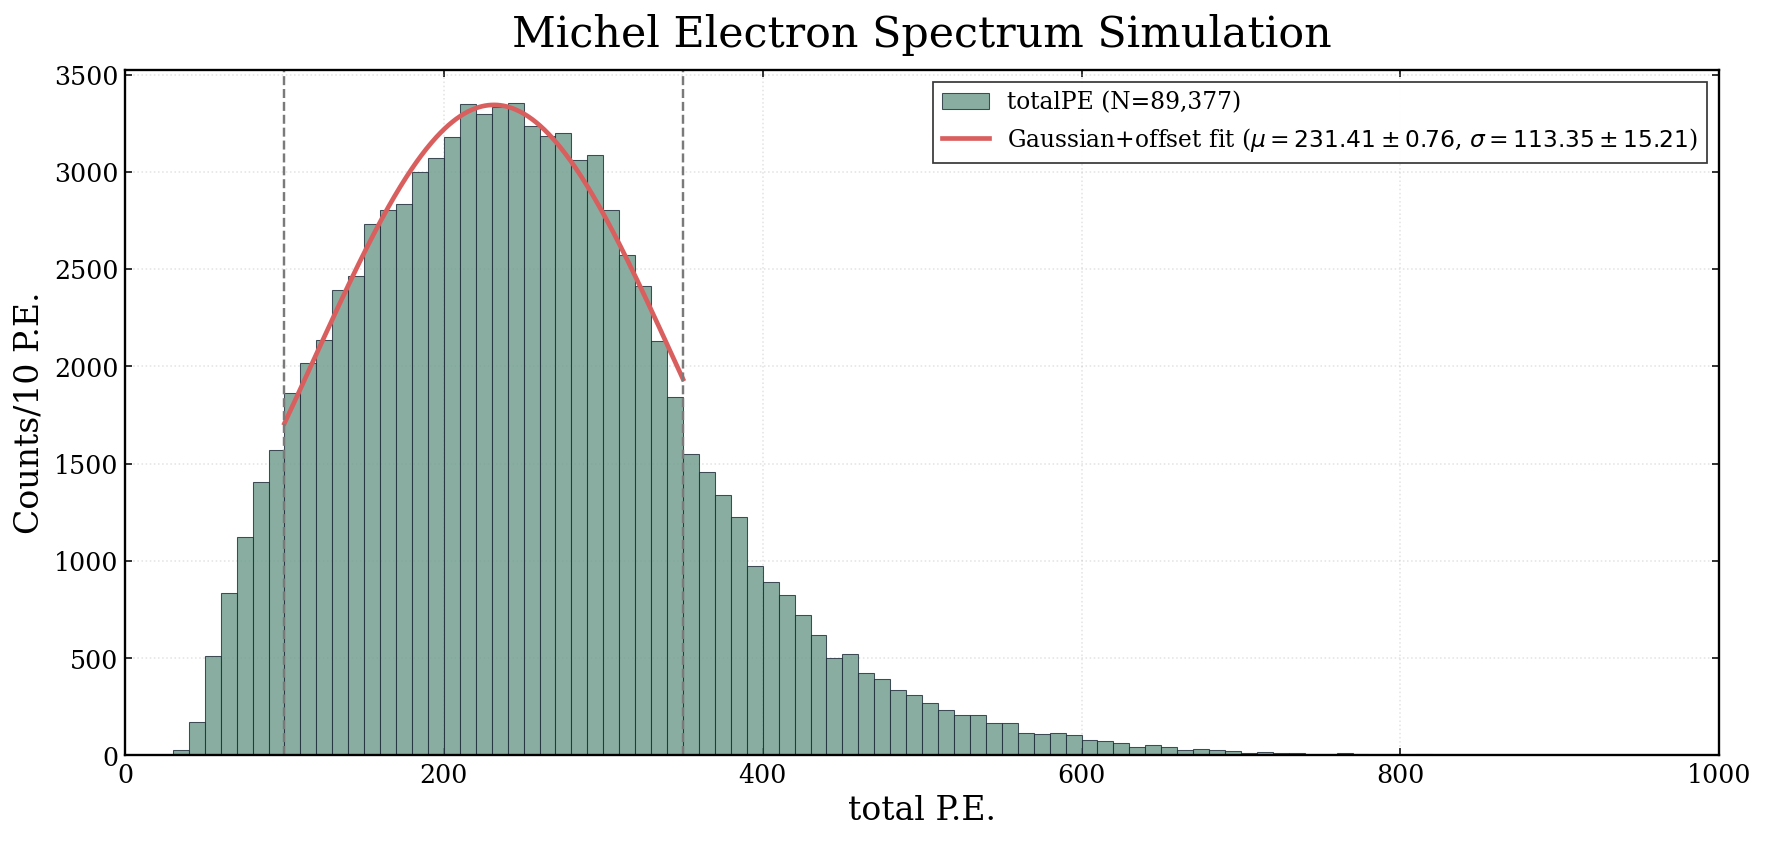

In [4]:
# Thesis-style histogram of totalPE with Gaussian-like fit around the physical peak (fit range = FWHM)
from scipy.optimize import curve_fit
from scipy.stats import norm

def gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def gauss_with_offset(x, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + C

totalPE_np = ak.to_numpy(totalPE)
totalPE_pos = totalPE_np[totalPE_np > 0]

if len(totalPE_pos) < 20:
    raise RuntimeError("Too few nonzero totalPE events for a stable peak fit.")

# Thesis-like plotting style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 17,
    "axes.titlesize": 22,
    "legend.fontsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.2
})

# Fixed binning requested: 0 to 1000 in steps of 10 P.E.
bin_width_pe = 10
bin_min_pe = 0
bin_max_pe = 1000
bin_edges_fixed = np.arange(bin_min_pe, bin_max_pe + bin_width_pe, bin_width_pe)

# Full histogram (fixed range 0-1000)
hist_full, edges_full = np.histogram(totalPE_np, bins=bin_edges_fixed)

# Fit histogram (nonzero events only, fixed range 0-1000)
hist_fit, edges_fit = np.histogram(totalPE_pos, bins=bin_edges_fixed)
centers_fit = 0.5 * (edges_fit[:-1] + edges_fit[1:])
bin_width = edges_fit[1] - edges_fit[0]

peak_idx = int(np.argmax(hist_fit))
peak_x = float(centers_fit[peak_idx])
peak_y = float(hist_fit[peak_idx])

if peak_y <= 0:
    raise RuntimeError("Unable to identify a nonzero peak for fitting in 0-1000 P.E. range.")

half_max = peak_y / 2.0

# Find FWHM bounds around nonzero peak
left_idx = peak_idx
while left_idx > 0 and hist_fit[left_idx] >= half_max:
    left_idx -= 1
right_idx = peak_idx
while right_idx < len(hist_fit) - 1 and hist_fit[right_idx] >= half_max:
    right_idx += 1

# Convert scan indices to bins inside the half-max region
left_in = left_idx + 1 if hist_fit[left_idx] < half_max else left_idx
right_in = right_idx - 1 if hist_fit[right_idx] < half_max else right_idx

# Safety fallback if FWHM interval collapses
if right_in < left_in:
    left_in = max(peak_idx - 1, 0)
    right_in = min(peak_idx + 1, len(hist_fit) - 1)

# Slightly widen fit window by one bin on each side for stability
left_in = max(left_in, 0)
right_in = min(right_in, len(hist_fit) - 1)

x_left = float(edges_fit[left_in])
x_right = float(edges_fit[right_in + 1])
fwhm = max(x_right - x_left, 1.0)

# Fit directly to histogram points in the FWHM window
fit_bin_mask = (centers_fit >= x_left) & (centers_fit <= x_right) & (hist_fit > 0)
x_fit = centers_fit[fit_bin_mask]
y_fit = hist_fit[fit_bin_mask].astype(float)

if len(x_fit) < 5:
    raise RuntimeError("Too few nonzero histogram bins in FWHM range for stable Gaussian fit.")

fit_method = "curve_fit (gauss+offset)"
try:
    c0 = max(0.0, float(np.percentile(y_fit, 20)))
    a0 = max(float(np.max(y_fit) - c0), 1.0)
    p0 = [a0, peak_x, max(fwhm / 2.355, 1.0), c0]

    y_err = np.sqrt(np.maximum(y_fit, 1.0))

    popt, pcov = curve_fit(
        gauss_with_offset,
        x_fit,
        y_fit,
        p0=p0,
        sigma=y_err,
        absolute_sigma=True,
        bounds=([0.0, x_left, 1e-6, 0.0], [np.inf, x_right, np.inf, np.inf]),
        maxfev=100000
    )

    A_fit, mu_fit, sigma_fit, C_fit = popt
    perr = np.sqrt(np.maximum(np.diag(pcov), 0.0))
    A_err, mu_err, sigma_err, C_err = perr
except Exception:
    fit_method = "norm.fit fallback"
    fit_data = totalPE_pos[(totalPE_pos >= x_left) & (totalPE_pos <= x_right)]
    if len(fit_data) < 10:
        raise RuntimeError("Fallback fit also failed due to too few events in fit range.")
    mu_fit, sigma_fit = norm.fit(fit_data)
    C_fit = 0.0
    A_fit = len(fit_data) * bin_width / (sigma_fit * np.sqrt(2 * np.pi))
    A_err = np.nan
    mu_err = sigma_fit / np.sqrt(len(fit_data))
    sigma_err = sigma_fit / np.sqrt(2 * len(fit_data))
    C_err = np.nan

x_smooth = np.linspace(x_left, x_right, 400)
y_smooth = gauss_with_offset(x_smooth, A_fit, mu_fit, sigma_fit, C_fit)

n_zero = np.sum(totalPE_np == 0)
n_all = len(totalPE_np)

# Muted thesis palette
hist_color = "#6F9C8D"
edge_color = "#1F2D3A"
fit_color = "#D95F5F"

# Wider rectangular figure
fig, ax = plt.subplots(figsize=(12.8, 6.2), dpi=140)

ax.hist(
    totalPE_np,
    bins=bin_edges_fixed,
    color=hist_color,
    edgecolor=edge_color,
    linewidth=0.55,
    alpha=0.82,
    label=f"totalPE (N={n_all:,})"
 )

ax.plot(
    x_smooth, y_smooth,
    color=fit_color,
    linewidth=2.4,
    label=f"Gaussian+offset fit ($\\mu={mu_fit:.2f}\\pm{mu_err:.2f}$, $\\sigma={sigma_fit:.2f}\\pm{sigma_err:.2f}$)"
 )

ax.axvline(x_left, color="#7A7A7A", linestyle="--", linewidth=1.25)
ax.axvline(x_right, color="#7A7A7A", linestyle="--", linewidth=1.25)

ax.set_title("Michel Electron Spectrum Simulation", pad=12)
ax.set_xlabel("total P.E.")
ax.set_ylabel(f"Counts/{bin_width_pe} P.E.")
ax.set_axisbelow(True)
ax.grid(True, which="major", linestyle=":", linewidth=0.8, alpha=0.35)

# Keep legend compact and show fit parameters directly in the fit label
legend = ax.legend(
    loc="upper right",
    frameon=True,
    framealpha=0.96,
    fancybox=False,
    edgecolor="#303030"
 )
legend.get_frame().set_linewidth(0.9)

ax.set_xlim(bin_min_pe, bin_max_pe)
plt.tight_layout()
plt.show()

In [5]:
#path to real data
path_data = "/raid1/genli/Data_D2O/M2_data/analysis_4598-4621_step1_M2_20260316-212222/MASTER_RESULTS/aggregated_total_pe_step1.pkl"


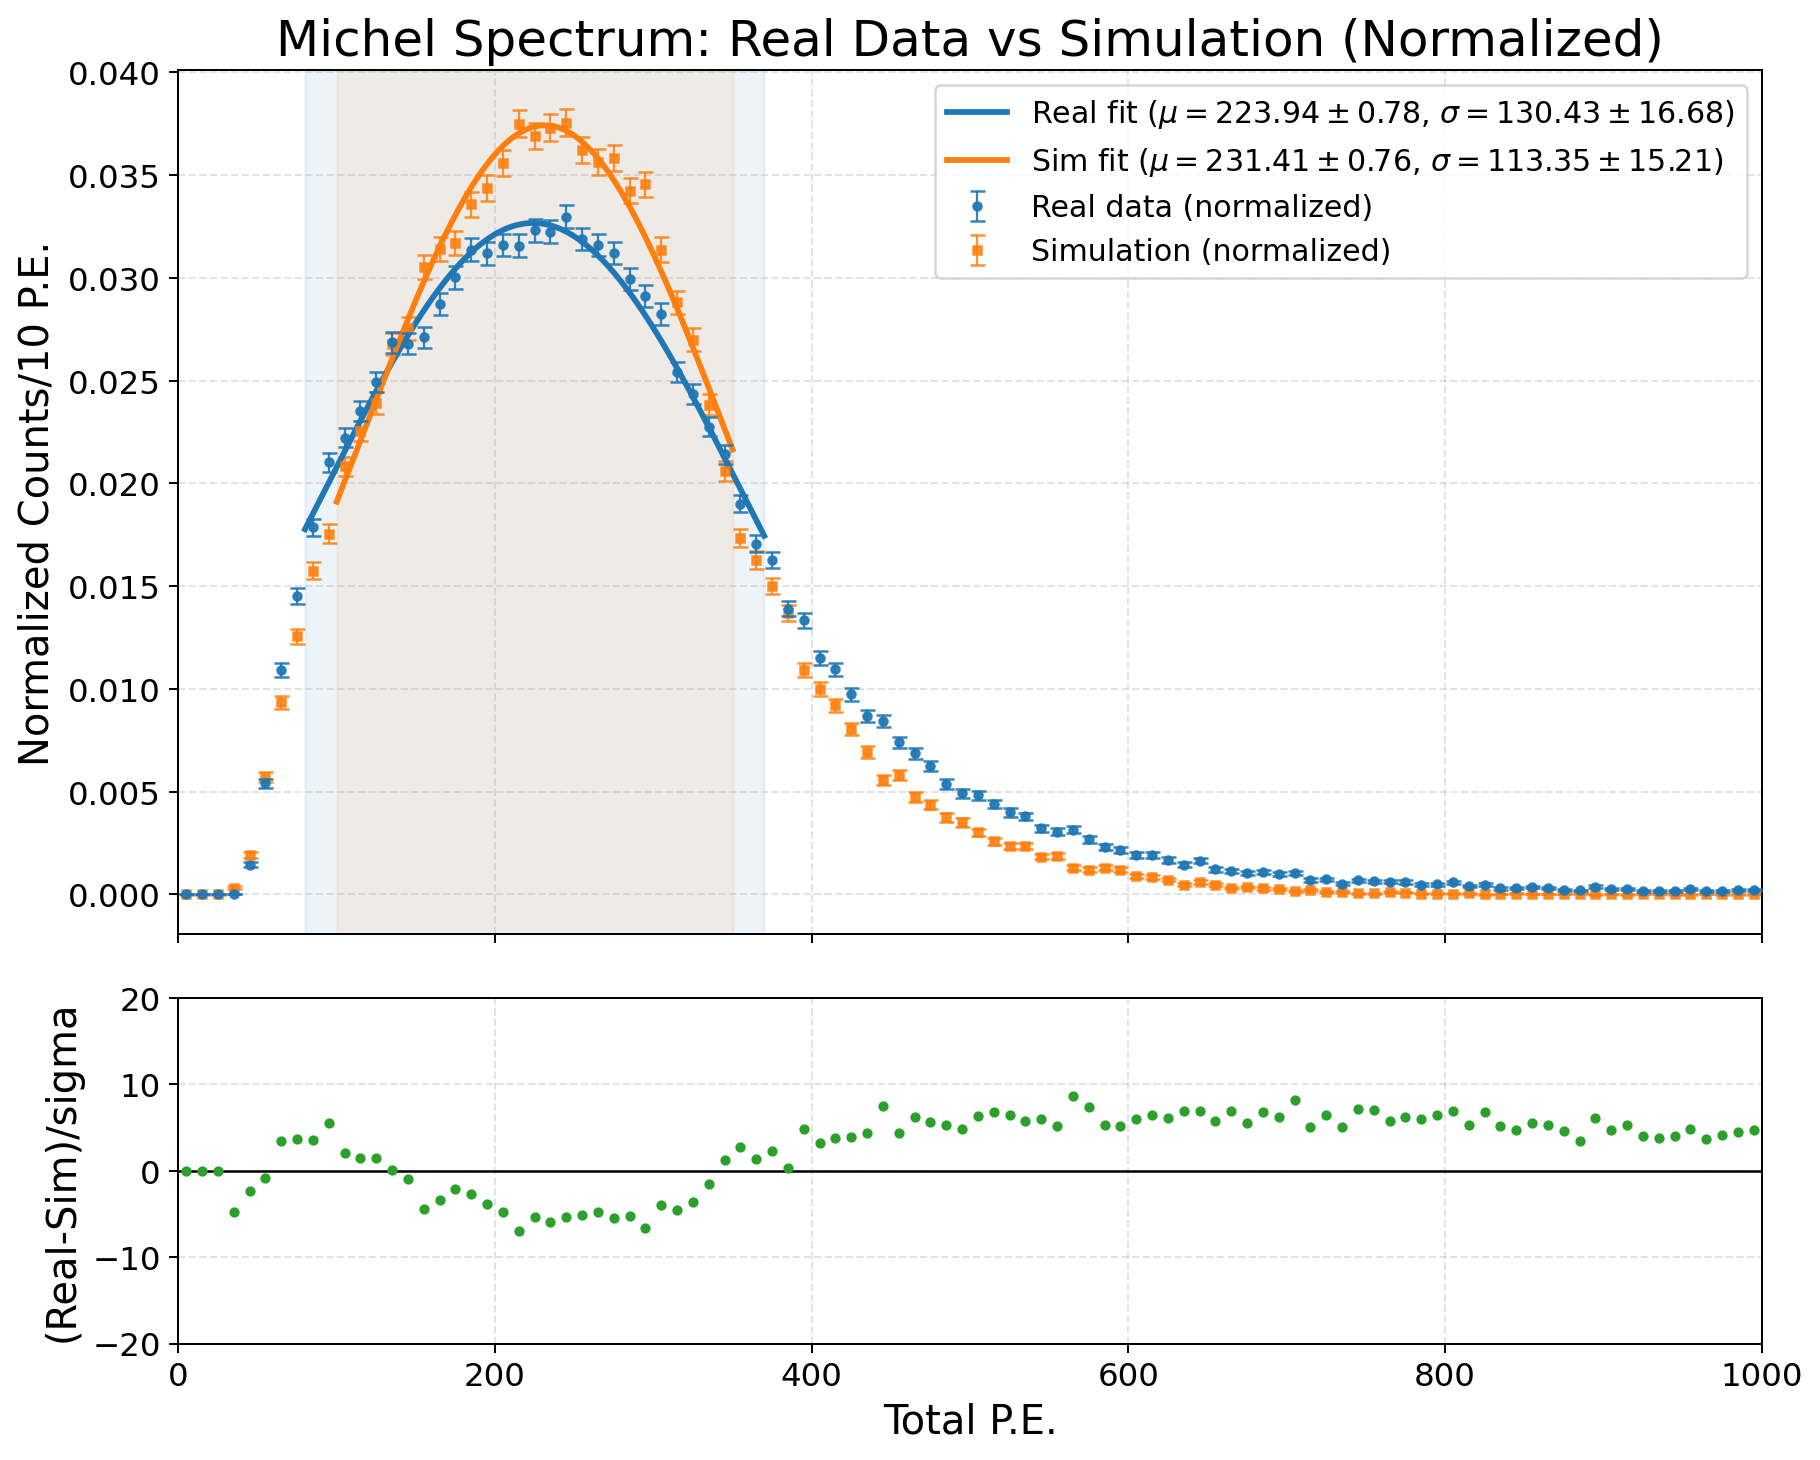

Gaussian fit comparison on normalized spectra (Cell-4 logic, fit on counts):
  Real data: mu = 223.94 +/- 0.78, sigma = 130.43 +/- 16.68
  Simulation: mu = 231.41 +/- 0.76, sigma = 113.35 +/- 15.21
  Delta mu (real - sim) = -7.47
  Delta sigma (real - sim) = 17.08
  Real fit method: curve_fit (gauss+offset)
  Sim fit method : curve_fit (gauss+offset)


In [6]:
# Compare real data vs simulation: normalized histogram + Cell-4-consistent fit logic
import pickle
from scipy.optimize import curve_fit
from scipy.stats import norm

def load_aggregated_data(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def _pick_series(series_like, preferred_key=None):
    if isinstance(series_like, dict):
        if preferred_key is not None and preferred_key in series_like:
            key = preferred_key
        elif "all" in series_like:
            key = "all"
        elif "total" in series_like:
            key = "total"
        else:
            key = next(iter(series_like))
        return np.asarray(series_like[key], dtype=float), key
    return np.asarray(series_like, dtype=float), preferred_key

def extract_real_spectrum(payload):
    x = None
    key = None
    for x_key in ["centers", "bin_centers", "bins", "x", "pe_centers"]:
        if x_key in payload:
            x, key = _pick_series(payload[x_key])
            break

    y = None
    y_key = None
    for y_key_name in ["spectrum", "histograms", "counts"]:
        if y_key_name in payload:
            y, y_key = _pick_series(payload[y_key_name], preferred_key=key)
            break

    if y is None:
        raise KeyError("Could not find spectrum-like key in real data file.")

    if x is None:
        x = np.arange(len(y), dtype=float)

    if "errors" in payload:
        yerr, _ = _pick_series(payload["errors"], preferred_key=y_key)
    elif "uncertainties" in payload:
        yerr, _ = _pick_series(payload["uncertainties"], preferred_key=y_key)
    else:
        yerr = np.sqrt(np.clip(y, 0, None))

    n = min(len(x), len(y), len(yerr))
    x = np.asarray(x[:n], dtype=float)
    y = np.asarray(y[:n], dtype=float)
    yerr = np.asarray(yerr[:n], dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    return x[mask], y[mask], yerr[mask]

def gauss_with_offset(x, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + C

def fit_hist_cell4_logic(hist_counts, edges, label="spectrum"):
    hist_counts = np.asarray(hist_counts, dtype=float)
    edges = np.asarray(edges, dtype=float)
    centers = 0.5 * (edges[:-1] + edges[1:])

    peak_idx = int(np.argmax(hist_counts))
    peak_x = float(centers[peak_idx])
    peak_y = float(hist_counts[peak_idx])
    if peak_y <= 0:
        raise RuntimeError(f"No positive peak found for {label}.")

    half_max = peak_y / 2.0
    left_idx = peak_idx
    while left_idx > 0 and hist_counts[left_idx] >= half_max:
        left_idx -= 1
    right_idx = peak_idx
    while right_idx < len(hist_counts) - 1 and hist_counts[right_idx] >= half_max:
        right_idx += 1

    left_in = left_idx + 1 if hist_counts[left_idx] < half_max else left_idx
    right_in = right_idx - 1 if hist_counts[right_idx] < half_max else right_idx
    if right_in < left_in:
        left_in = max(peak_idx, 0)
        right_in = min(peak_idx, len(hist_counts) - 1)

    x_left = float(edges[left_in])
    x_right = float(edges[right_in + 1])
    fwhm = max(x_right - x_left, 1.0)

    fit_bin_mask = (centers >= x_left) & (centers <= x_right) & (hist_counts > 0)
    x_fit = centers[fit_bin_mask]
    y_fit = hist_counts[fit_bin_mask]
    if len(x_fit) < 5:
        raise RuntimeError(f"Too few nonzero histogram bins in FWHM range for {label}.")

    fit_method = "curve_fit (gauss+offset)"
    try:
        c0 = max(0.0, float(np.percentile(y_fit, 20)))
        a0 = max(float(np.max(y_fit) - c0), 1.0)
        p0 = [a0, peak_x, max(fwhm / 2.355, 1.0), c0]
        y_err = np.sqrt(np.maximum(y_fit, 1.0))
        popt, pcov = curve_fit(
            gauss_with_offset,
            x_fit,
            y_fit,
            p0=p0,
            sigma=y_err,
            absolute_sigma=True,
            bounds=([0.0, x_left, 1e-6, 0.0], [np.inf, x_right, np.inf, np.inf]),
            maxfev=100000,
        )
        perr = np.sqrt(np.maximum(np.diag(pcov), 0.0))
        A_fit, mu_fit, sigma_fit, C_fit = popt
        A_err, mu_err, sigma_err, C_err = perr
    except Exception:
        fit_method = "norm.fit fallback"
        bin_width = edges[1] - edges[0]
        fit_data = np.repeat(x_fit, np.maximum(np.rint(y_fit).astype(int), 0))
        if len(fit_data) < 10:
            raise RuntimeError(f"Fallback fit failed for {label} due to too few pseudo-events.")
        mu_fit, sigma_fit = norm.fit(fit_data)
        C_fit = 0.0
        A_fit = len(fit_data) * bin_width / (sigma_fit * np.sqrt(2 * np.pi))
        A_err = np.nan
        mu_err = sigma_fit / np.sqrt(len(fit_data))
        sigma_err = sigma_fit / np.sqrt(2 * len(fit_data))
        C_err = np.nan

    return {
        "A": float(A_fit),
        "mu": float(mu_fit),
        "sigma": float(abs(sigma_fit)),
        "C": float(C_fit),
        "A_err": float(A_err),
        "mu_err": float(mu_err),
        "sigma_err": float(sigma_err),
        "C_err": float(C_err),
        "left": float(x_left),
        "right": float(x_right),
        "method": fit_method,
    }

# 1) Read real data spectrum
real_payload = load_aggregated_data(path_data)
if not isinstance(real_payload, dict):
    raise TypeError(f"Expected dict from real data file, got {type(real_payload)}")

x_real_raw, y_real_raw, e_real_raw = extract_real_spectrum(real_payload)

# 2) Build fixed histograms: 0-1000, step 10 P.E.
if "totalPE" not in globals():
    raise RuntimeError("Run Cell 3 first to produce totalPE from simulation.")

bin_min_pe = 0.0
bin_max_pe = 1000.0
bin_width_pe = 10.0
edges_fixed = np.arange(bin_min_pe, bin_max_pe + bin_width_pe, bin_width_pe)
x_centers_fixed = 0.5 * (edges_fixed[:-1] + edges_fixed[1:])

sim_values = ak.to_numpy(totalPE).astype(float)
sim_values = sim_values[np.isfinite(sim_values)]
sim_values = sim_values[sim_values >= 0]
y_sim_counts, _ = np.histogram(sim_values, bins=edges_fixed)

y_real_counts, _ = np.histogram(x_real_raw, bins=edges_fixed, weights=y_real_raw)
yerr2_real_counts, _ = np.histogram(x_real_raw, bins=edges_fixed, weights=np.square(e_real_raw))
e_real_counts = np.sqrt(np.maximum(yerr2_real_counts, 1e-12))
e_sim_counts = np.sqrt(np.maximum(y_sim_counts, 1.0))

# 3) Normalize both spectra to unit area for shape comparison
norm_real = float(np.sum(y_real_counts))
norm_sim = float(np.sum(y_sim_counts))
if norm_real <= 0 or norm_sim <= 0:
    raise RuntimeError("Cannot normalize spectra because one of them has zero total counts in 0-1000 P.E. range.")

x_real = x_centers_fixed.copy()
y_real = y_real_counts / norm_real
e_real = e_real_counts / norm_real

x_sim = x_centers_fixed.copy()
y_sim = y_sim_counts / norm_sim
e_sim = e_sim_counts / norm_sim

# 4) Fit raw-count histograms using Cell-4 logic, then normalize curves for plotting
fit_real_counts = fit_hist_cell4_logic(y_real_counts, edges_fixed, label="real data (counts)")
fit_sim_counts = fit_hist_cell4_logic(y_sim_counts, edges_fixed, label="simulation (counts)")

x_fit_real = np.linspace(fit_real_counts["left"], fit_real_counts["right"], 400)
x_fit_sim = np.linspace(fit_sim_counts["left"], fit_sim_counts["right"], 400)
y_fit_real = gauss_with_offset(
    x_fit_real, fit_real_counts["A"], fit_real_counts["mu"], fit_real_counts["sigma"], fit_real_counts["C"]
) / norm_real
y_fit_sim = gauss_with_offset(
    x_fit_sim, fit_sim_counts["A"], fit_sim_counts["mu"], fit_sim_counts["sigma"], fit_sim_counts["C"]
) / norm_sim

# 5) Plot: normalized histogram comparison + fit overlay
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 13,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "legend.fontsize": 12,
})

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10.0, 8.0), dpi=180,
    gridspec_kw={"height_ratios": [3.0, 1.2], "hspace": 0.06},
    sharex=True,
    constrained_layout=True
)

ax_top.errorbar(
    x_real, y_real, yerr=e_real, fmt="o", ms=3.2, lw=0.9, capsize=3.0,
    color="tab:blue", ecolor="tab:blue", alpha=0.90,
    label="Real data (normalized)", zorder=3
)
ax_top.errorbar(
    x_sim, y_sim, yerr=e_sim, fmt="s", ms=3.0, lw=0.9, capsize=3.0,
    color="tab:orange", ecolor="tab:orange", alpha=0.85,
    label="Simulation (normalized)", zorder=2
)

ax_top.plot(
    x_fit_real, y_fit_real, color="tab:blue", lw=2.3,
    label=f"Real fit ($\\mu={fit_real_counts['mu']:.2f}\\pm{fit_real_counts['mu_err']:.2f}$, $\\sigma={fit_real_counts['sigma']:.2f}\\pm{fit_real_counts['sigma_err']:.2f}$)"
)
ax_top.plot(
    x_fit_sim, y_fit_sim, color="tab:orange", lw=2.3,
    label=f"Sim fit ($\\mu={fit_sim_counts['mu']:.2f}\\pm{fit_sim_counts['mu_err']:.2f}$, $\\sigma={fit_sim_counts['sigma']:.2f}\\pm{fit_sim_counts['sigma_err']:.2f}$)"
)

ax_top.axvspan(fit_real_counts["left"], fit_real_counts["right"], color="tab:blue", alpha=0.08)
ax_top.axvspan(fit_sim_counts["left"], fit_sim_counts["right"], color="tab:orange", alpha=0.08)

ax_top.set_title("Michel Spectrum: Real Data vs Simulation (Normalized)")
ax_top.set_ylabel(f"Normalized Counts/{bin_width_pe:.0f} P.E.")
ax_top.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.35)
ax_top.legend(loc="upper right", frameon=True)

# Bottom panel: pull-like difference on normalized spectra
y_sim_interp = np.interp(x_real, x_sim, y_sim, left=np.nan, right=np.nan)
e_sim_interp = np.interp(x_real, x_sim, e_sim, left=np.nan, right=np.nan)
sigma_comb = np.sqrt(e_real**2 + e_sim_interp**2)
pull = (y_real - y_sim_interp) / np.where(sigma_comb > 0, sigma_comb, np.nan)
valid = np.isfinite(pull)

ax_bot.axhline(0, color="black", lw=1.0)
ax_bot.plot(x_real[valid], pull[valid], "o", ms=3.1, color="tab:green")
ax_bot.set_xlabel("Total P.E.")
ax_bot.set_ylabel("(Real-Sim)/sigma")
ax_bot.set_ylim(-20, 20)
ax_bot.set_xlim(bin_min_pe, bin_max_pe)
ax_bot.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.35)

plt.show()

# 6) Print fit comparison summary (shape comparison)
print("Gaussian fit comparison on normalized spectra (Cell-4 logic, fit on counts):")
print(f"  Real data: mu = {fit_real_counts['mu']:.2f} +/- {fit_real_counts['mu_err']:.2f}, sigma = {fit_real_counts['sigma']:.2f} +/- {fit_real_counts['sigma_err']:.2f}")
print(f"  Simulation: mu = {fit_sim_counts['mu']:.2f} +/- {fit_sim_counts['mu_err']:.2f}, sigma = {fit_sim_counts['sigma']:.2f} +/- {fit_sim_counts['sigma_err']:.2f}")
print(f"  Delta mu (real - sim) = {fit_real_counts['mu'] - fit_sim_counts['mu']:.2f}")
print(f"  Delta sigma (real - sim) = {fit_real_counts['sigma'] - fit_sim_counts['sigma']:.2f}")
print(f"  Real fit method: {fit_real_counts['method']}")
print(f"  Sim fit method : {fit_sim_counts['method']}")

Caliberation

Loaded files:
  /raid1/genli/G4d2o_simulations/batch_20260323_212122/job_0/Sim_D2ODetector000.root
  /raid1/genli/G4d2o_simulations/batch_20260323_212122/job_1/Sim_D2ODetector001.root
  /raid1/genli/G4d2o_simulations/batch_20260323_212122/job_2/Sim_D2ODetector002.root
  /raid1/genli/G4d2o_simulations/batch_20260323_212122/job_3/Sim_D2ODetector003.root
  /raid1/genli/G4d2o_simulations/batch_20260323_212122/job_4/Sim_D2ODetector004.root
  /raid1/genli/G4d2o_simulations/batch_20260323_212122/job_5/Sim_D2ODetector005.root
  /raid1/genli/G4d2o_simulations/batch_20260323_212122/job_6/Sim_D2ODetector006.root

Cutflow summary:
file                         before      after   efficiency
Sim_D2ODetector000.root      100000      75900       0.7590
Sim_D2ODetector001.root      100000      75489       0.7549
Sim_D2ODetector002.root      100000      75727       0.7573
Sim_D2ODetector003.root      100000      75968       0.7597
Sim_D2ODetector004.root      100000      75682       0.7568
Sim_D2ODetect

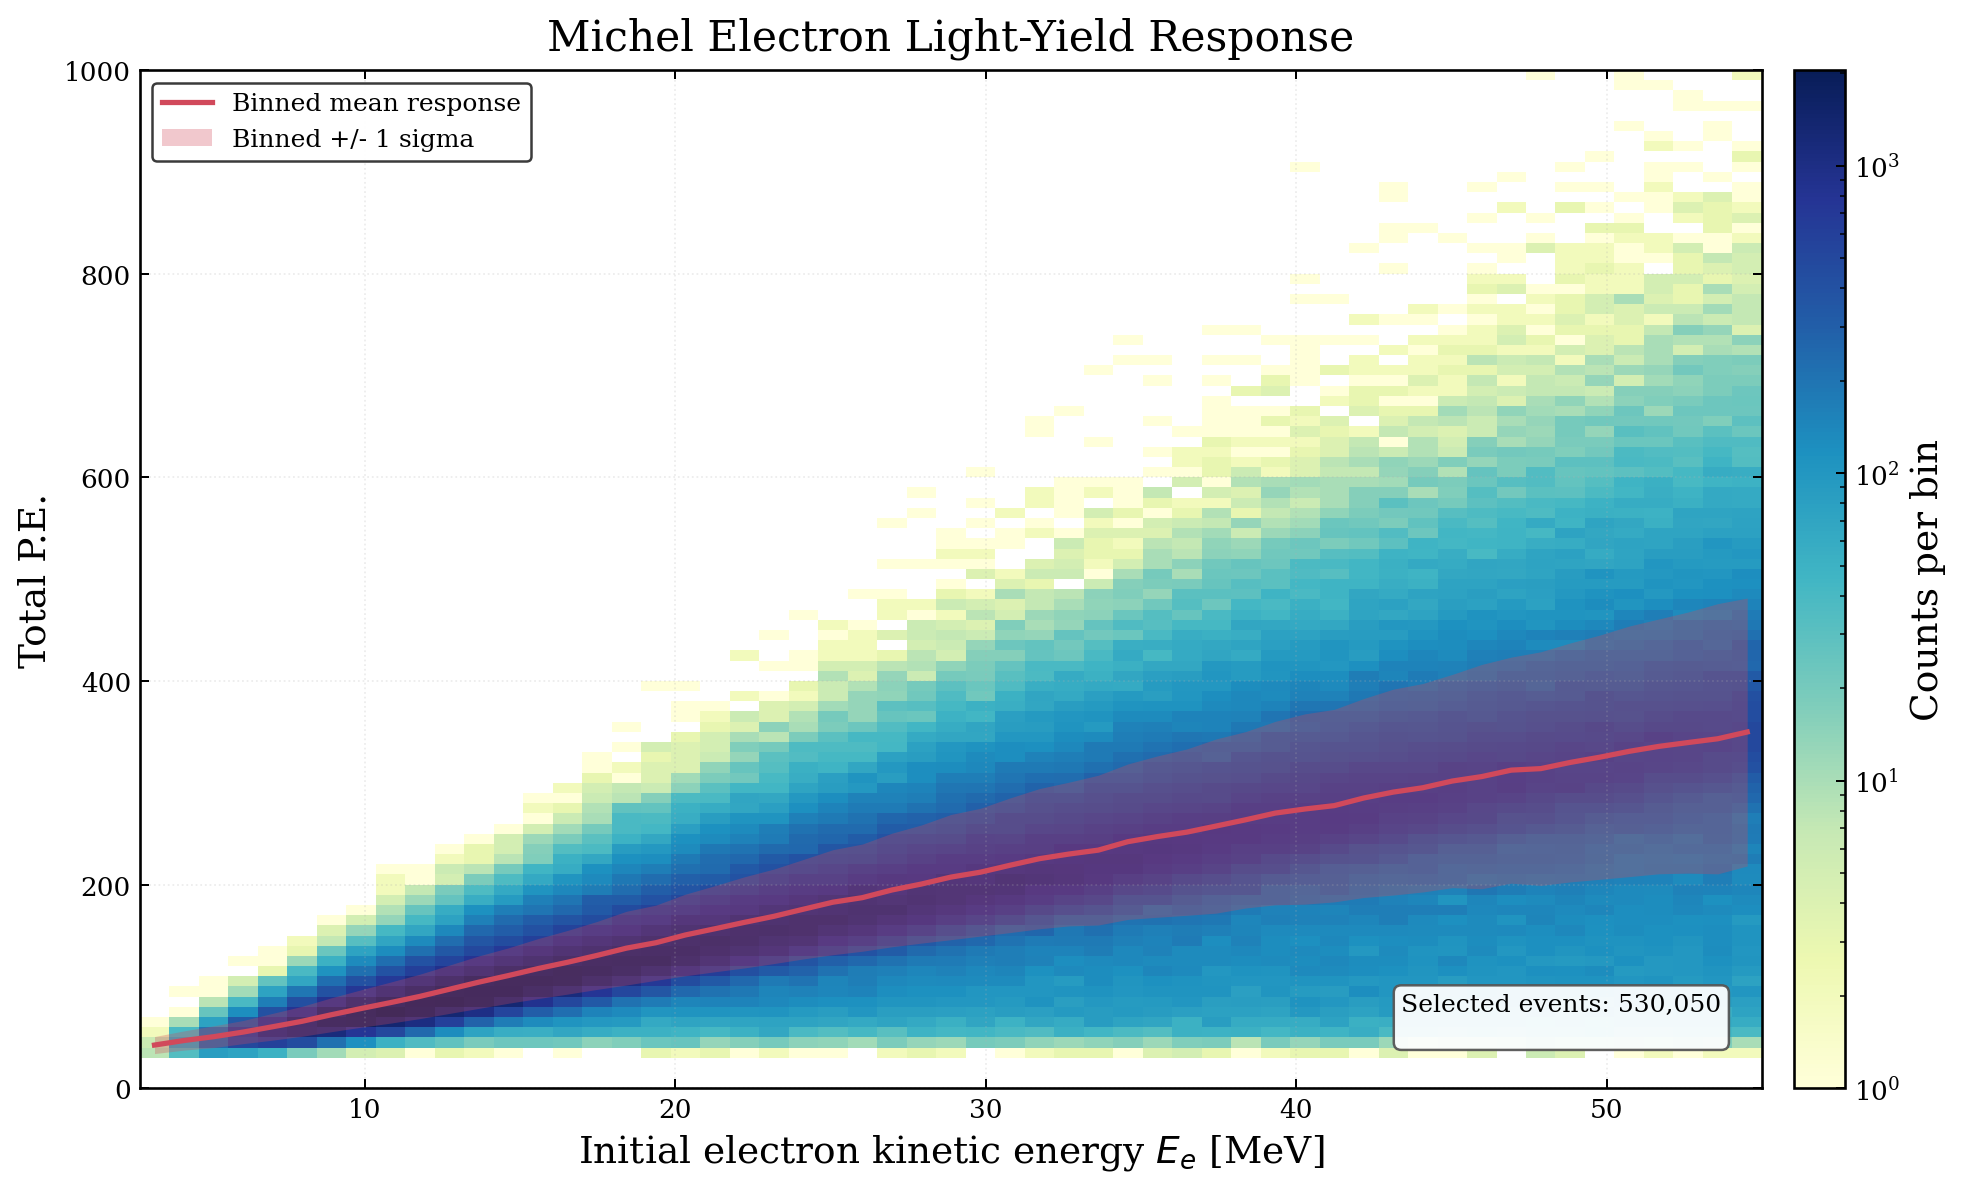

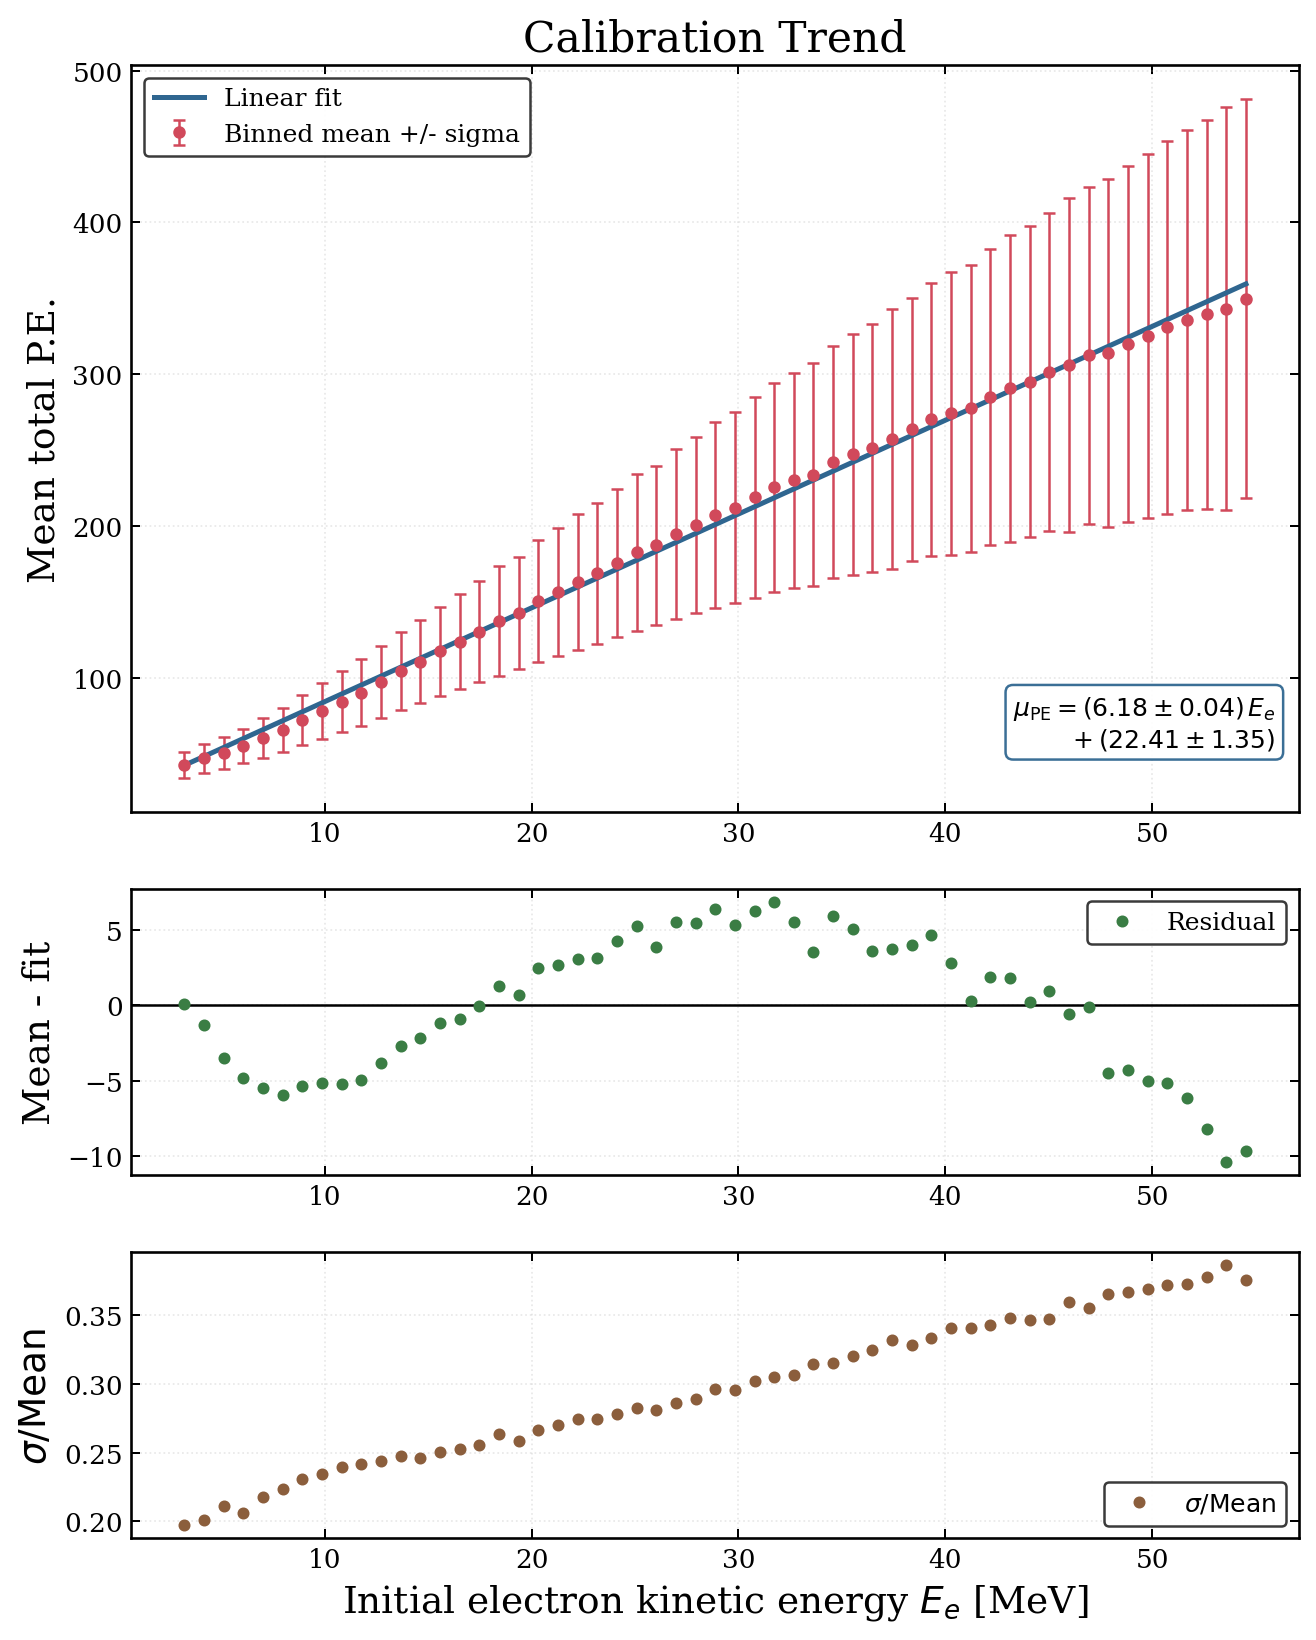

In [19]:
# Load the full Michel simulation batch, apply the quality cut, and make thesis-ready calibration plots
from pathlib import Path
from matplotlib.colors import LogNorm

base_dir = Path("/raid1/genli/G4d2o_simulations/batch_20260323_212122")
root_paths = [base_dir / f"job_{job_index}" / f"Sim_D2ODetector{job_index:03d}.root" for job_index in range(7)]

missing_paths = [str(path) for path in root_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing expected ROOT files:\n" + "\n".join(missing_paths))

def passes_quality_cut(pmt_nums, required_pmts=12, min_hits_per_pmt=2):
    evt_np = np.asarray(ak.to_numpy(pmt_nums), dtype=np.int64)
    if evt_np.size == 0:
        return False
    counts = np.bincount(evt_np, minlength=required_pmts)[:required_pmts]
    return np.all(counts >= min_hits_per_pmt)

source_energy_chunks = []
totalpe_chunks = []
cutflow_rows = []

for path in root_paths:
    with uproot.open(path) as root_file:
        event_data = root_file["Sim_Tree"]["eventData"]
        source_energy = event_data["sourceParticleEnergy"].array(library="np")
        pmt_hits = event_data["pmtHits"].array()
        pmt_num = pmt_hits["pmtHits.pmtNum"]

        n_events_before = len(source_energy)
        pass_mask = np.fromiter((
            passes_quality_cut(event_pmts) for event_pmts in pmt_num
        ), dtype=bool, count=n_events_before)

        source_energy_sel = source_energy[pass_mask]
        totalpe_sel = ak.to_numpy(ak.num(pmt_num[pass_mask], axis=1)).astype(np.int64)

        source_energy_chunks.append(source_energy_sel)
        totalpe_chunks.append(totalpe_sel)
        cutflow_rows.append((
            path.name,
            n_events_before,
            int(np.count_nonzero(pass_mask)),
            float(np.count_nonzero(pass_mask) / n_events_before) if n_events_before else 0.0,
        ))

E_electron = np.concatenate(source_energy_chunks) if source_energy_chunks else np.array([], dtype=float)
totalPE_batch = np.concatenate(totalpe_chunks) if totalpe_chunks else np.array([], dtype=np.int64)

if E_electron.size == 0 or totalPE_batch.size == 0:
    raise RuntimeError("No events survived the quality cut across the selected files.")

totalPE = totalPE_batch

print("Loaded files:")
for path in root_paths:
    print(f"  {path}")

print("\nCutflow summary:")
print(f"{'file':<24} {'before':>10} {'after':>10} {'efficiency':>12}")
for file_name, before_count, after_count, efficiency in cutflow_rows:
    print(f"{file_name:<24} {before_count:>10d} {after_count:>10d} {efficiency:>12.4f}")

print("\nSelected sample summary:")
print(f"  Events after cut : {len(E_electron):,}")
print(f"  Mean E_electron  : {np.mean(E_electron):.3f} MeV")
print(f"  Std E_electron   : {np.std(E_electron):.3f} MeV")
print(f"  Mean totalPE     : {np.mean(totalPE):.2f}")
print(f"  Std totalPE      : {np.std(totalPE):.2f}")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 15,
    "axes.titlesize": 17,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.05,
})

energy_min = max(0.0, float(np.floor(E_electron.min() * 20.0) / 20.0))
energy_max = float(np.ceil(E_electron.max() * 20.0) / 20.0)
pe_max = float(max(1000.0, np.ceil(np.percentile(totalPE, 99.5) / 20.0) * 20.0))

energy_bins = np.linspace(energy_min, energy_max, 56)
pe_bins = np.arange(0.0, pe_max + 10.0, 10.0)

energy_centers = 0.5 * (energy_bins[:-1] + energy_bins[1:])
digitized = np.digitize(E_electron, energy_bins) - 1
mean_totalpe = np.full(len(energy_centers), np.nan)
std_totalpe = np.full(len(energy_centers), np.nan)

for bin_index in range(len(energy_centers)):
    in_bin = digitized == bin_index
    if np.count_nonzero(in_bin) >= 5:
        mean_totalpe[bin_index] = np.mean(totalPE[in_bin])
        std_totalpe[bin_index] = np.std(totalPE[in_bin])

valid_profile = np.isfinite(mean_totalpe)
fit_x = energy_centers[valid_profile]
fit_y = mean_totalpe[valid_profile]
fit_sigma = std_totalpe[valid_profile]

if len(fit_x) >= 2:
    linear_coeffs, linear_cov = np.polyfit(fit_x, fit_y, deg=1, cov=True)
    linear_fit = np.polyval(linear_coeffs, fit_x)
    linear_residual = fit_y - linear_fit
    sigma_over_mean = fit_sigma / fit_y
    slope, intercept = linear_coeffs
    slope_err, intercept_err = np.sqrt(np.diag(linear_cov))
else:
    linear_coeffs = np.array([np.nan, np.nan])
    linear_cov = np.full((2, 2), np.nan)
    linear_fit = np.full_like(fit_x, np.nan)
    linear_residual = np.full_like(fit_x, np.nan)
    sigma_over_mean = np.full_like(fit_x, np.nan)
    slope, intercept = np.nan, np.nan
    slope_err, intercept_err = np.nan, np.nan

summary_text = (
    f"Selected events: {len(E_electron):,}\n"
 )

fig_response = plt.figure(figsize=(10.8, 6.5), dpi=180, constrained_layout=True)
ax_main = fig_response.add_subplot(111)

hist2d = ax_main.hist2d(
    E_electron,
    totalPE,
    bins=[energy_bins, pe_bins],
    cmap="YlGnBu",
    norm=LogNorm(vmin=1),
)

cbar = fig_response.colorbar(hist2d[3], ax=ax_main, fraction=0.046, pad=0.02)
cbar.set_label("Counts per bin")

ax_main.plot(
    fit_x,
    fit_y,
    color="#D1495B",
    linewidth=2.1,
    label="Binned mean response",
)
ax_main.fill_between(
    fit_x,
    fit_y - std_totalpe[valid_profile],
    fit_y + std_totalpe[valid_profile],
    color="#D1495B",
    alpha=0.3,
    linewidth=0,
    label="Binned +/- 1 sigma",
)
ax_main.set_title("Michel Electron Light-Yield Response", pad=8)
ax_main.set_xlabel(r"Initial electron kinetic energy $E_e$ [MeV]")
ax_main.set_ylabel("Total P.E.")
ax_main.grid(True, linestyle=":", linewidth=0.7, alpha=0.24)
ax_main.legend(loc="upper left", frameon=True, framealpha=0.95, edgecolor="#303030")
ax_main.text(
    0.975, 0.045, summary_text,
    transform=ax_main.transAxes,
    ha="right",
    va="bottom",
    fontsize=10.0,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.94, "edgecolor": "#555555"},
)

ax_main.set_xlim(energy_bins[0], energy_bins[-1])
ax_main.set_ylim(pe_bins[0], pe_bins[-1])

plt.show()

fig_calibration = plt.figure(figsize=(7.2, 9.0), dpi=180, constrained_layout=True)
grid_calibration = fig_calibration.add_gridspec(3, 1, height_ratios=[3.0, 1.15, 1.15], hspace=0.08)

ax_profile = fig_calibration.add_subplot(grid_calibration[0])
ax_cal_residual = fig_calibration.add_subplot(grid_calibration[1], sharex=ax_profile)
ax_sigma_ratio = fig_calibration.add_subplot(grid_calibration[2], sharex=ax_profile)

ax_profile.errorbar(
    fit_x,
    fit_y,
    yerr=fit_sigma,
    fmt="o",
    ms=4.0,
    lw=1.0,
    capsize=2.4,
    color="#D1495B",
    ecolor="#D1495B",
    label="Binned mean +/- sigma",
)
if len(fit_x) >= 2:
    ax_profile.plot(
        fit_x, linear_fit,
        color="#2F6690",
        linewidth=2.0,
        label="Linear fit"
    )
ax_profile.set_title("Calibration Trend", pad=6)
ax_profile.set_ylabel("Mean total P.E.")
ax_profile.grid(True, linestyle=":", linewidth=0.7, alpha=0.28)
ax_profile.legend(loc="upper left", frameon=True, framealpha=0.95, edgecolor="#303030")

if len(fit_x) >= 2:
    linear_text = (
        rf"$\mu_{{\mathrm{{PE}}}} = ({slope:.2f} \pm {slope_err:.2f})\,E_e$"
        "\n"
        rf"$\quad + ({intercept:.2f} \pm {intercept_err:.2f})$"
    )
    ax_profile.text(
        0.98, 0.08, linear_text,
        transform=ax_profile.transAxes,
        ha="right",
        va="bottom",
        fontsize=10.0,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.94, "edgecolor": "#2F6690"},
    )

ax_cal_residual.axhline(0.0, color="black", linewidth=1.0)
if len(fit_x) >= 2:
    ax_cal_residual.plot(
        fit_x, linear_residual,
        "o",
        ms=3.8,
        color="#3A7D44",
        label="Residual"
    )
ax_cal_residual.set_ylabel("Mean - fit")
ax_cal_residual.grid(True, linestyle=":", linewidth=0.7, alpha=0.28)
ax_cal_residual.legend(loc="upper right", frameon=True, framealpha=0.95, edgecolor="#303030")

if len(fit_x) >= 2:
    ax_sigma_ratio.plot(
        fit_x, sigma_over_mean,
        "o",
        ms=3.8,
        color="#8B5E3C",
        label=r"$\sigma/\mathrm{Mean}$"
    )
ax_sigma_ratio.set_xlabel(r"Initial electron kinetic energy $E_e$ [MeV]")
ax_sigma_ratio.set_ylabel(r"$\sigma/\mathrm{Mean}$")
ax_sigma_ratio.grid(True, linestyle=":", linewidth=0.7, alpha=0.28)
ax_sigma_ratio.legend(loc="lower right", frameon=True, framealpha=0.95, edgecolor="#303030")

plt.show()

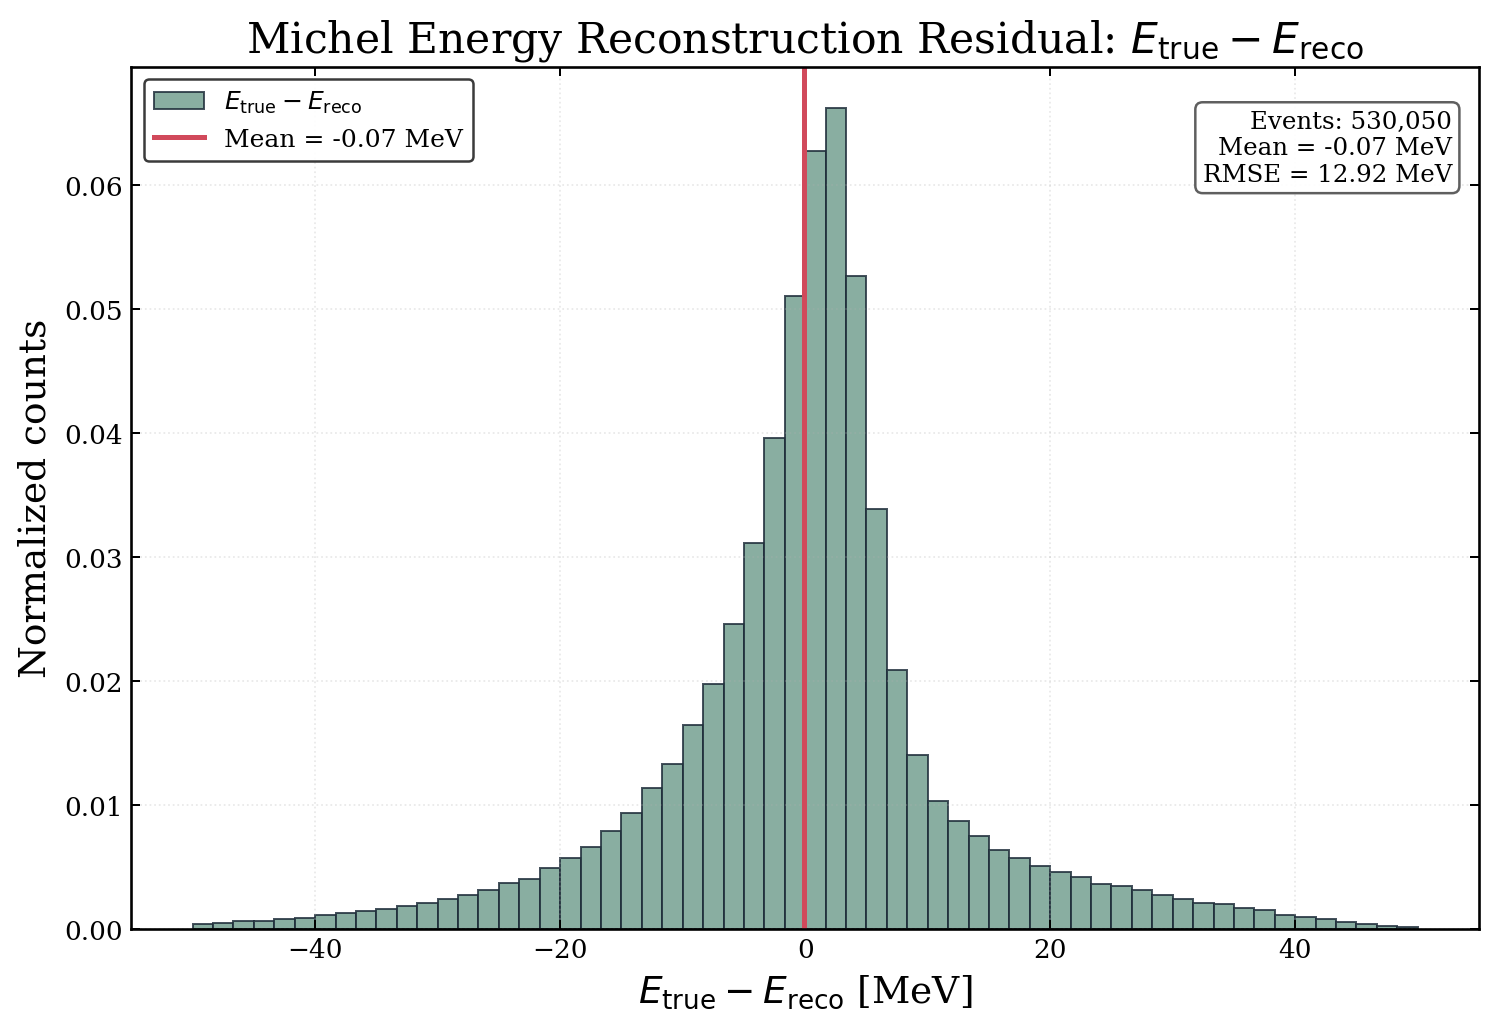

Reconstruction residual summary:
  Events used                 : 530,050
  Mean true E                 : 32.013 MeV
  Mean reconstructed E        : 32.088 MeV
  Mean (true - reco)          : -0.075 MeV
  Std  (true - reco)          : 12.922 MeV
  RMSE                        : 12.922 MeV


In [16]:
# Based on the linear calibration fit, convert totalPE to reconstructed electron energy and plot the distribution of true minus reconstructed energy
if "totalPE" not in globals() or "E_electron" not in globals():
    raise RuntimeError("Run Cell 8 first so totalPE and E_electron are available.")

if "slope" not in globals() or "intercept" not in globals():
    raise RuntimeError("Run Cell 8 first so the linear calibration parameters are available.")

if not np.isfinite(slope) or not np.isfinite(intercept) or abs(slope) < 1e-12:
    raise RuntimeError("Linear calibration parameters are invalid for energy reconstruction.")

E_reco = (totalPE - intercept) / slope
valid_reco = np.isfinite(E_reco) & np.isfinite(E_electron)

if np.count_nonzero(valid_reco) == 0:
    raise RuntimeError("No finite reconstructed energies were produced.")

E_true = E_electron[valid_reco]
E_reconstructed = E_reco[valid_reco]
delta_E = E_true - E_reconstructed

delta_mean = np.mean(delta_E)
delta_std = np.std(delta_E)
delta_rmse = np.sqrt(np.mean(delta_E**2))

delta_limit = float(np.ceil(np.percentile(np.abs(delta_E), 99.5) / 2.0) * 2.0)
delta_limit = max(delta_limit, 20.0)
delta_bins = np.linspace(-delta_limit, delta_limit, 61)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 15,
    "axes.titlesize": 17,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.05,
})

fig_delta, ax_delta = plt.subplots(figsize=(8.2, 5.6), dpi=180, constrained_layout=True)

ax_delta.hist(
    delta_E,
    bins=delta_bins,
    density=True,
    color="#6F9C8D",
    edgecolor="#1F2D3A",
    linewidth=0.8,
    alpha=0.82,
    label=r"$E_{\mathrm{true}} - E_{\mathrm{reco}}$"
 )
ax_delta.axvline(0.0, color="black", linewidth=1.0, linestyle="--")
ax_delta.axvline(delta_mean, color="#D1495B", linewidth=2.0, label=fr"Mean = {delta_mean:.2f} MeV")

delta_summary = (
    f"Events: {len(delta_E):,}\n"
    f"Mean = {delta_mean:.2f} MeV\n"
    # f"Std = {delta_std:.2f} MeV\n"
    f"RMSE = {delta_rmse:.2f} MeV"
)

ax_delta.text(
    0.98, 0.95, delta_summary,
    transform=ax_delta.transAxes,
    ha="right",
    va="top",
    fontsize=9.8,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.94, "edgecolor": "#555555"},
)
ax_delta.set_title(r"Michel Energy Reconstruction Residual: $E_{\mathrm{true}} - E_{\mathrm{reco}}$", pad=6)
ax_delta.set_xlabel(r"$E_{\mathrm{true}} - E_{\mathrm{reco}}$ [MeV]")
ax_delta.set_ylabel("Normalized counts")
ax_delta.grid(True, linestyle=":", linewidth=0.7, alpha=0.28)
ax_delta.legend(loc="upper left", frameon=True, framealpha=0.95, edgecolor="#303030")

plt.show()

print("Reconstruction residual summary:")
print(f"  Events used                 : {len(delta_E):,}")
print(f"  Mean true E                 : {np.mean(E_true):.3f} MeV")
print(f"  Mean reconstructed E        : {np.mean(E_reconstructed):.3f} MeV")
print(f"  Mean (true - reco)          : {delta_mean:.3f} MeV")
print(f"  Std  (true - reco)          : {delta_std:.3f} MeV")
print(f"  RMSE                        : {delta_rmse:.3f} MeV")